# Training model 

In [1]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.4 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import yaml
import torch
import numpy as np
from PIL import Image

In [3]:
def convert_bbox_to_yolo(box, img_width, img_height):
   
    x1, y1, x2, y2 = box
    x_center = (x1 + x2) / 2.0 / img_width
    y_center = (y1 + y2) / 2.0 / img_height
    
    width = (x2 - x1) / img_width
    height = (y2 - y1) / img_height
    
    x_center = min(max(0, x_center), 1.0)
    y_center = min(max(0, y_center), 1.0)
    width = min(max(0, width), 1.0)
    height = min(max(0, height), 1.0)
    
    return [x_center, y_center, width, height]



In [4]:
DATA_DIR = '/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset'
OUTPUT_DIR = 'output'

In [5]:
from tqdm import tqdm 

def prepare_yolo_dataset(dataset_dir='data/Dataset', output_dir='data/yolo_dataset', train_val_ratio: float = 0.9):

    os.makedirs(output_dir + '/images/train', exist_ok=True)
    os.makedirs(output_dir + '/images/val', exist_ok=True)
    os.makedirs(output_dir + '/labels/train', exist_ok=True)
    os.makedirs(output_dir + '/labels/val', exist_ok=True)

    img_dir = os.path.join(dataset_dir, 'Train/images')
    label_dir = os.path.join(dataset_dir, 'Train/labels')
    
    image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    
   
    np.random.shuffle(image_files)
    split_idx = int(len(image_files) * train_val_ratio)
    train_images = image_files[:split_idx]
    val_images = image_files[split_idx:]
    
    print("Create training image")
    for img_file in tqdm(train_images):
        # Copy ảnh
        img_path = os.path.join(img_dir, img_file)
        img = Image.open(img_path)
        img_width, img_height = img.size
        img.save(os.path.join(output_dir, 'images/train', img_file))
        
        label_file = img_file.replace('.jpg', '.txt')
        label_path = os.path.join(label_dir, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                annotations = f.readlines()
                
            with open(os.path.join(output_dir, 'labels/train', label_file), 'w') as out_file:
                for line in annotations:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x1, y1, x2, y2 = map(float, parts[1:])
                
                    yolo_box = convert_bbox_to_yolo([x1, y1, x2, y2], img_width, img_height)

                    out_file.write(f"{class_id} {yolo_box[0]} {yolo_box[1]} {yolo_box[2]} {yolo_box[3]}\n")
    
    print("Create validation folder")
    for img_file in tqdm(val_images):
        img_path = os.path.join(img_dir, img_file)
        img = Image.open(img_path)
        img_width, img_height = img.size
        img.save(os.path.join(output_dir, 'images/val', img_file))
        
        label_file = img_file.replace('.jpg', '.txt')
        label_path = os.path.join(label_dir, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                annotations = f.readlines()
                
            with open(os.path.join(output_dir, 'labels/val', label_file), 'w') as out_file:
                for line in annotations:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x1, y1, x2, y2 = map(float, parts[1:])
                    yolo_box = convert_bbox_to_yolo([x1, y1, x2, y2], img_width, img_height)
                    out_file.write(f"{class_id} {yolo_box[0]} {yolo_box[1]} {yolo_box[2]} {yolo_box[3]}\n")
    

    unique_classes = list(range(6))  
    class_names = {i: f"class_{i}" for i in unique_classes}
    
    data_config = {
        "path": os.path.abspath(output_dir),
        "train": "images/train",
        "val": "images/val",
        "nc": len(unique_classes),
        "names": class_names
    }
    
    with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    
    print(f"Dataset đã được chuyển đổi sang định dạng YOLO tại: {output_dir}")
    return os.path.join(output_dir, 'data.yaml')

In [ ]:
prepare_yolo_dataset(DATA_DIR, OUTPUT_DIR)

Create training image


  8%|▊         | 535/6867 [00:10<02:01, 51.99it/s]

In [ ]:
from ultralytics import YOLO
import torch
import wandb 



def train_yolo(model_path, data_yaml_path):

    wandb.login(key=WANDB_API_KEY)
    
    run = wandb.init(
        project="fruit-detection",
        name="yolov8-fruit-detection",
    )
    
    model = YOLO(model_path) 
    
    results = model.train(
        data=data_yaml_path,  
        epochs=50,            
        imgsz=640,           
        batch=16,            
        workers=4,            
        device=0,             
        project='fruit-detection-yolo',  
        name='yolo11s',       
        save=True,            
        verbose=True,       
        seed=42, 
        pretrained=True, 
    )

   
    
    val_results = model.val()
    metrics = val_results.box
    
    wandb.log({
        "val/mAP50": metrics.map50,      
        "val/mAP50-95": metrics.map,     
        "val/precision": metrics.mp,    
        "val/recall": metrics.mr,        
    })
    print(f"Validation results: {val_results}")

    
    wandb.finish()
    
    return model, results

In [8]:
 train_yolo_direct('/kaggle/input/yolo11/pytorch/default/3/best.pt', '/kaggle/working/output/data.yaml')

In [9]:
model = YOLO('/kaggle/input/yolo11/pytorch/default/3/best.pt')

In [10]:
image_path = "/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test/images/0026df6bcaf93ac5_jpg.rf.510f06f5d706b8924f3a8a411211dcf8.jpg"
predictions = model.predict(image_path, conf=0.25)


image 1/1 /kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test/images/0026df6bcaf93ac5_jpg.rf.510f06f5d706b8924f3a8a411211dcf8.jpg: 640x640 2 class_5s, 9.1ms
Speed: 9.2ms preprocess, 9.1ms inference, 353.3ms postprocess per image at shape (1, 3, 640, 640)


In [11]:
predictions[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'class_0', 1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4', 5: 'class_5'}
obb: None
orig_img: array([[[199, 134,  66],
        [200, 135,  67],
        [203, 135,  68],
        ...,
        [ 77,  49,  15],
        [ 78,  50,  16],
        [ 80,  52,  18]],

       [[199, 134,  66],
        [199, 134,  66],
        [202, 134,  67],
        ...,
        [ 77,  49,  15],
        [ 78,  50,  16],
        [ 80,  52,  18]],

       [[198, 133,  64],
        [198, 133,  64],
        [201, 134,  65],
        ...,
        [ 79,  48,  15],
        [ 78,  50,  16],
        [ 80,  52,  18]],

       ...,

       [[148,  88,  66],
        [155,  95,  73],
        [161, 101,  79],
        ...,
        [ 58,  27,   4],
        [ 59,  27,   4],
        [ 58,  27,   4]],

       [[133,  74,  54],
        [144,  85,  65],
        [155,  96,  76],
     

In [12]:
predictions[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 5.], device='cuda:0')
conf: tensor([0.9858, 0.9326], device='cuda:0')
data: tensor([[313.3766, 230.8596, 622.3660, 637.7445,   0.9858,   5.0000],
        [215.5005, 172.4109, 368.8660, 303.3097,   0.9326,   5.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([2, 6])
xywh: tensor([[467.8713, 434.3020, 308.9894, 406.8849],
        [292.1833, 237.8603, 153.3655, 130.8988]], device='cuda:0')
xywhn: tensor([[0.7310, 0.6786, 0.4828, 0.6358],
        [0.4565, 0.3717, 0.2396, 0.2045]], device='cuda:0')
xyxy: tensor([[313.3766, 230.8596, 622.3660, 637.7445],
        [215.5005, 172.4109, 368.8660, 303.3097]], device='cuda:0')
xyxyn: tensor([[0.4897, 0.3607, 0.9724, 0.9965],
        [0.3367, 0.2694, 0.5764, 0.4739]], device='cuda:0')

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

def visualize_yolo_predictions(model, base_path, ids, conf_threshold=0.25, figsize=(12, 12), ground_truth: bool = None):
    
    image_path = base_path + '/images/' + ids + '.jpg'
    results = model.predict(image_path, conf=conf_threshold)
    result = results[0]

    
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    
    colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan', 'magenta']
    
    
    class_names = {
        0: "Apple",
        1: "Banana", 
        2: "Grapes",
        3: "Orange", 
        4: "Pineapple",
        5: "Watermelon"
    }
    
    boxes = result.boxes.xyxy.cpu().numpy() 
    confs = result.boxes.conf.cpu().numpy()
    class_ids = result.boxes.cls.cpu().numpy().astype(int)

    if ground_truth: 
        ground_truth_path = base_path + '/labels/' + ids + '.txt'
        
        if os.path.exists(ground_truth_path):
            with open(ground_truth_path, 'r') as f:
                annotations = f.readlines()
            
            
            for line in annotations:
                parts = line.strip().split()
                label = int(parts[0]) 
                x1, y1, x2, y2 = map(float, parts[1:])
                
                color = colors[(label + 1) % len(colors)]
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')  
                ax.add_patch(rect)

                class_name = class_names.get(label, f"class_{label}")
                label = f"{class_name}: Ground Truth"
                ax.text(
                    x1, y1-10, label, fontsize=12, color='white', 
                    bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=3)
                )

    
    
    for box, conf, class_id in zip(boxes, confs, class_ids):
        x1, y1, x2, y2 = box
        

        color = colors[class_id % len(colors)]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')        
        ax.add_patch(rect)
        
        class_name = class_names.get(class_id, f"class_{class_id}")
        label = f"{class_name}: {conf:.2f}"
        ax.text(
            x1, y1-10, label, fontsize=12, color='white', 
            bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=3)
        )
    
    ax.set_title(f"YOLO Predictions - {len(boxes)} objects detected", fontsize=16)
    ax.axis('off')
  
    plt.tight_layout()
    plt.show()
    
    return fig, ax



In [14]:
BASE_TRAIN_PATH = '/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Train'



image 1/1 /kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Train/images/0000a16e4b057580_jpg.rf.00ab48988370f64f5ca8ea43ff64beab.jpg: 640x640 7 class_5s, 9.0ms
Speed: 2.4ms preprocess, 9.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


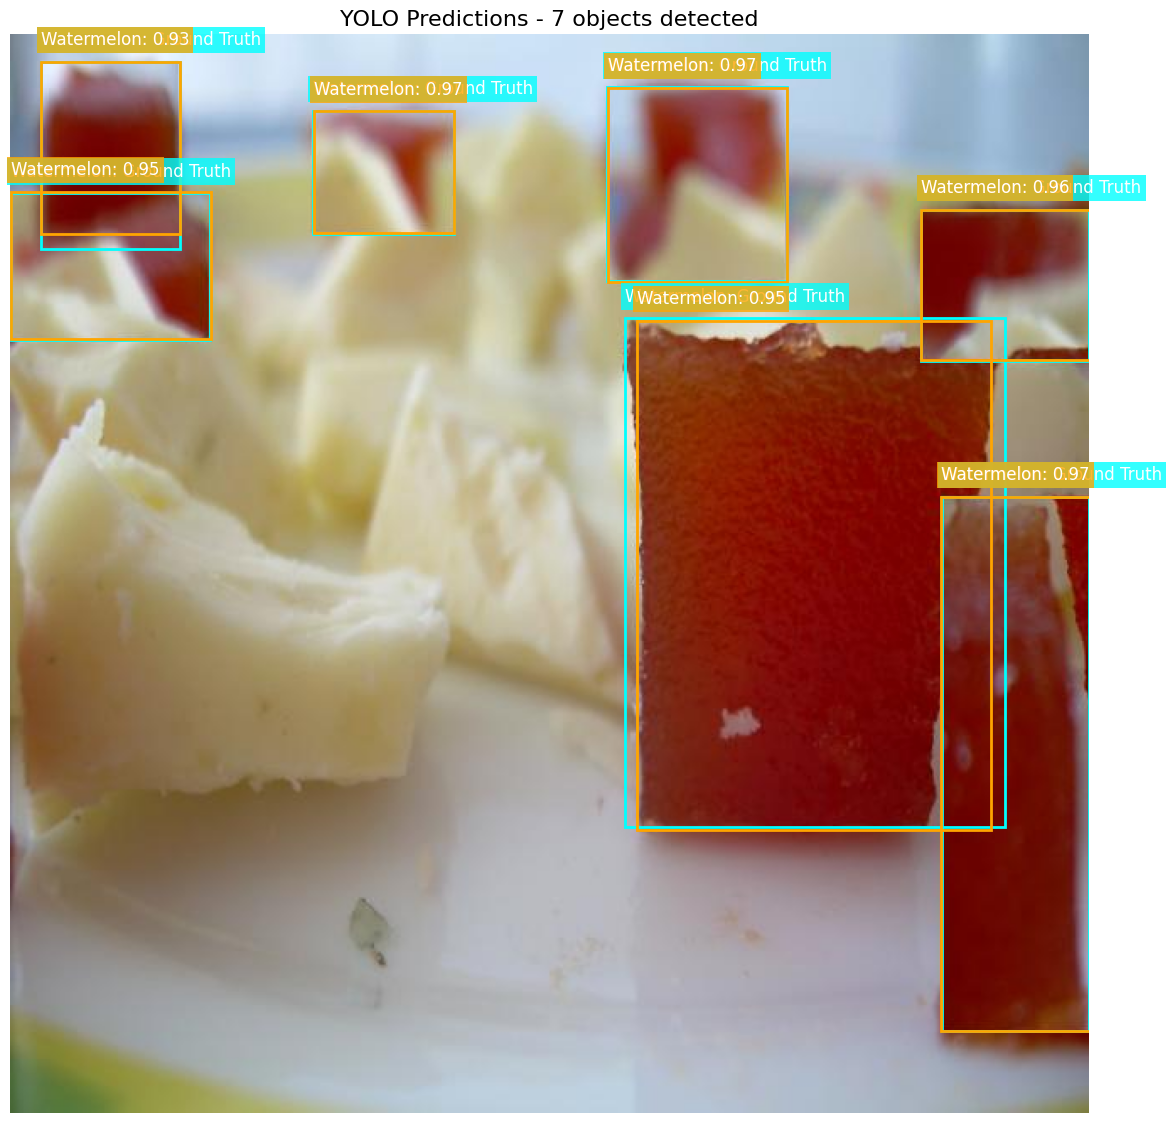

In [15]:
ids = "0000a16e4b057580_jpg.rf.00ab48988370f64f5ca8ea43ff64beab"  
fig, ax = visualize_yolo_predictions(model, BASE_TRAIN_PATH, ids, conf_threshold=0.25,ground_truth = True )


image 1/1 /kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Train/images/0009e57c20c24d4a_jpg.rf.de60f71a5b0c71caaa81427798cbfac8.jpg: 640x640 1 class_2, 10.4ms
Speed: 1.8ms preprocess, 10.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


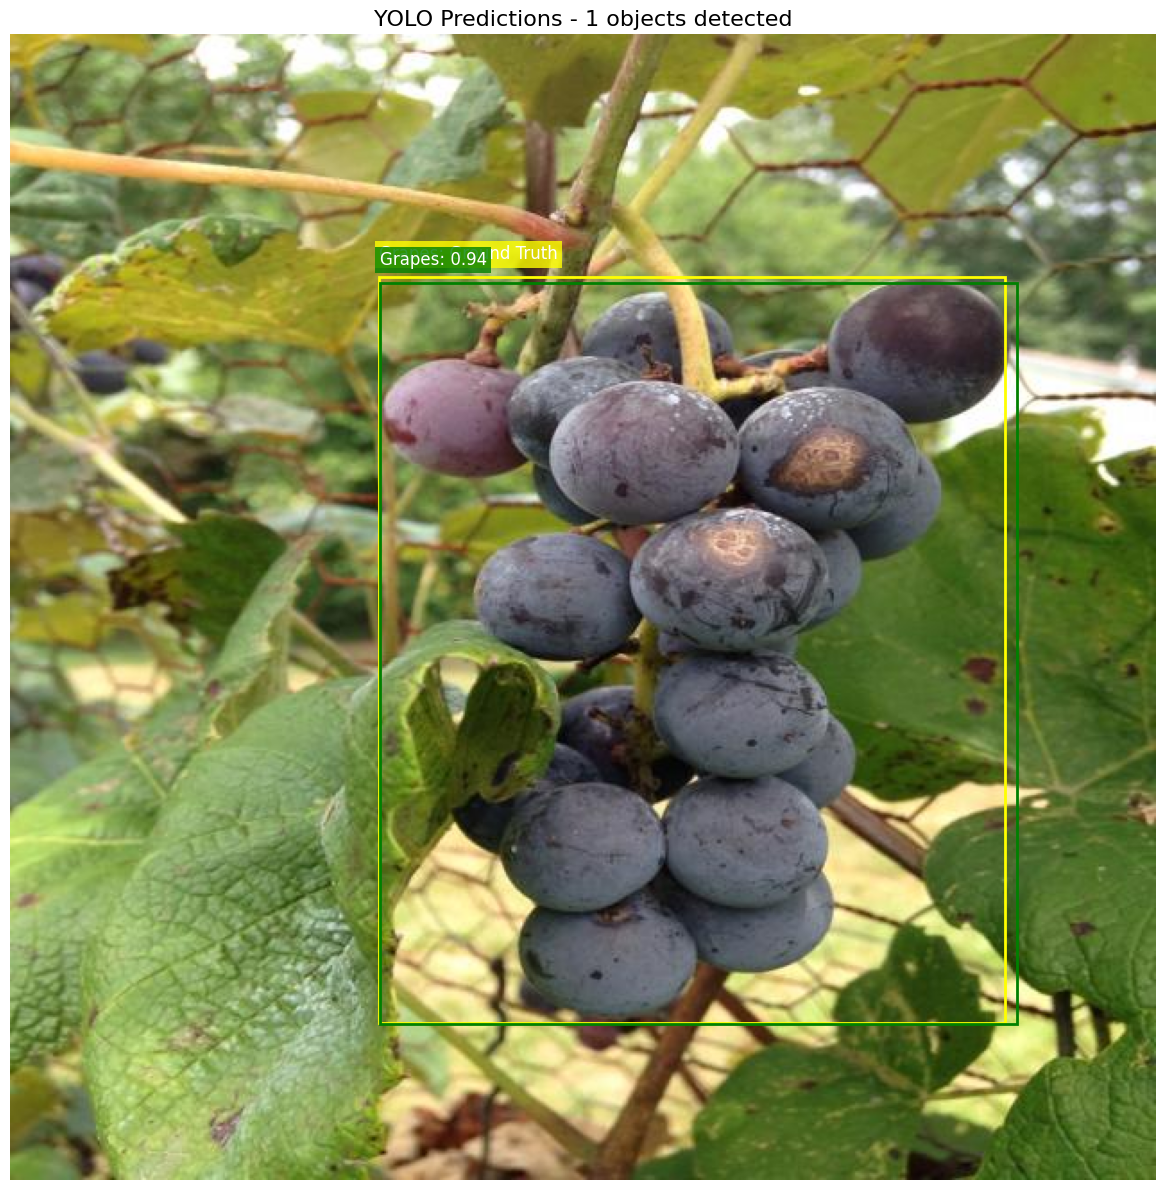

In [16]:
ids = "0009e57c20c24d4a_jpg.rf.de60f71a5b0c71caaa81427798cbfac8"  
fig, ax = visualize_yolo_predictions(model, BASE_TRAIN_PATH, ids, conf_threshold=0.5,ground_truth = True )


image 1/1 /kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Train/images/003be557ebbb9e8c_jpg.rf.e318d81621e7f5a46766332415f5863d.jpg: 640x640 8 class_5s, 10.0ms
Speed: 1.8ms preprocess, 10.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


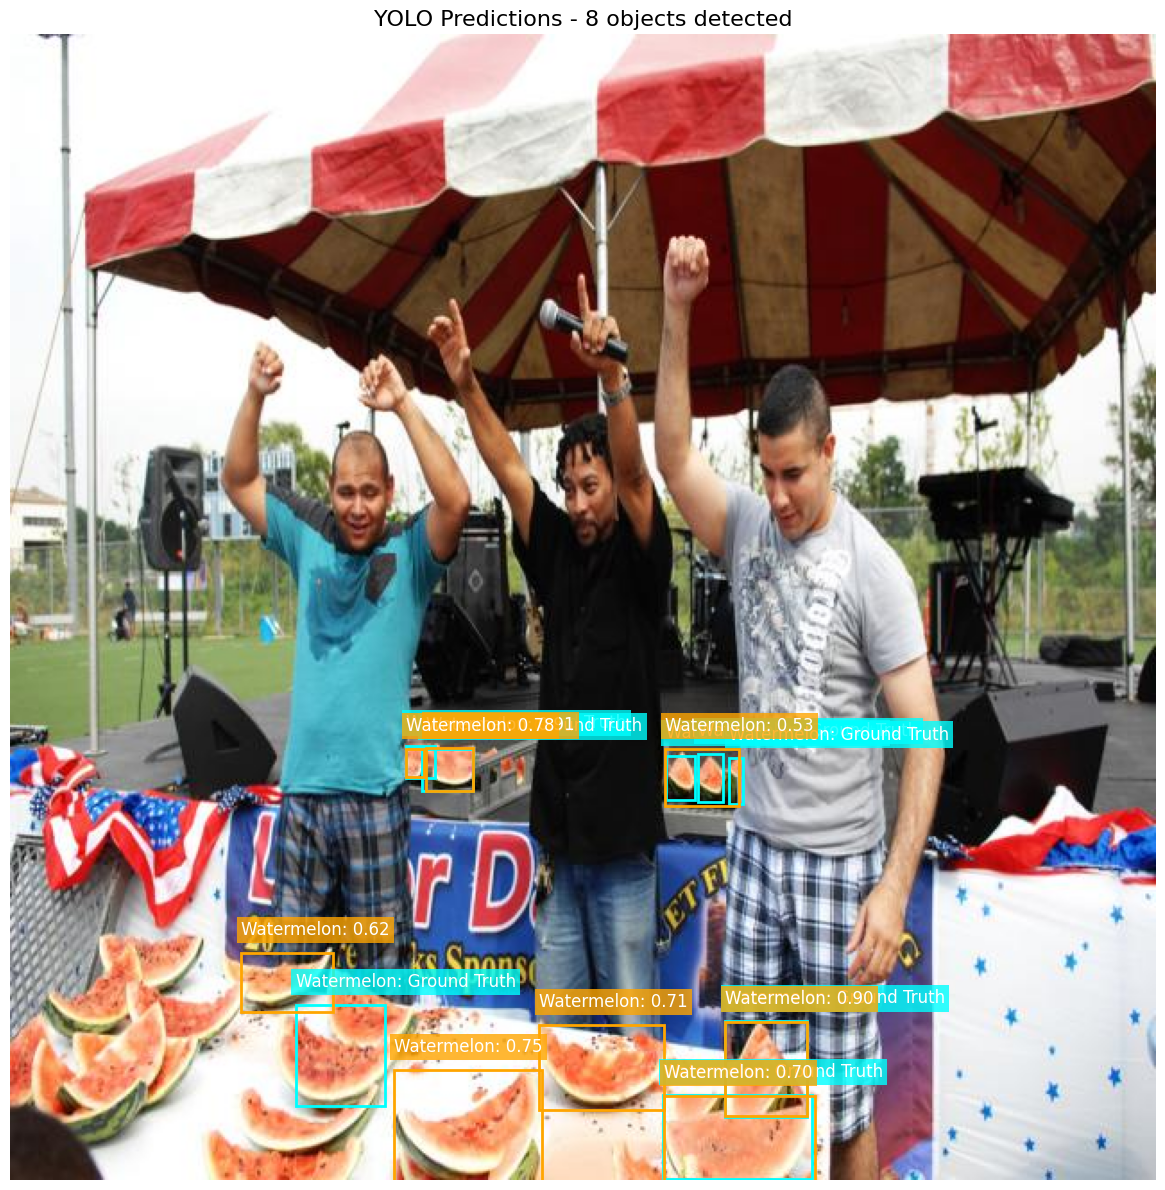

In [17]:
ids = "003be557ebbb9e8c_jpg.rf.e318d81621e7f5a46766332415f5863d"  
fig, ax = visualize_yolo_predictions(model, BASE_TRAIN_PATH, ids, conf_threshold=0.5,ground_truth = True )


image 1/1 /kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test/images/afd4e66481afd1b6_jpg.rf.fe2b55fb9817b9473b7b5561c5c1b733.jpg: 640x640 (no detections), 9.8ms
Speed: 1.8ms preprocess, 9.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


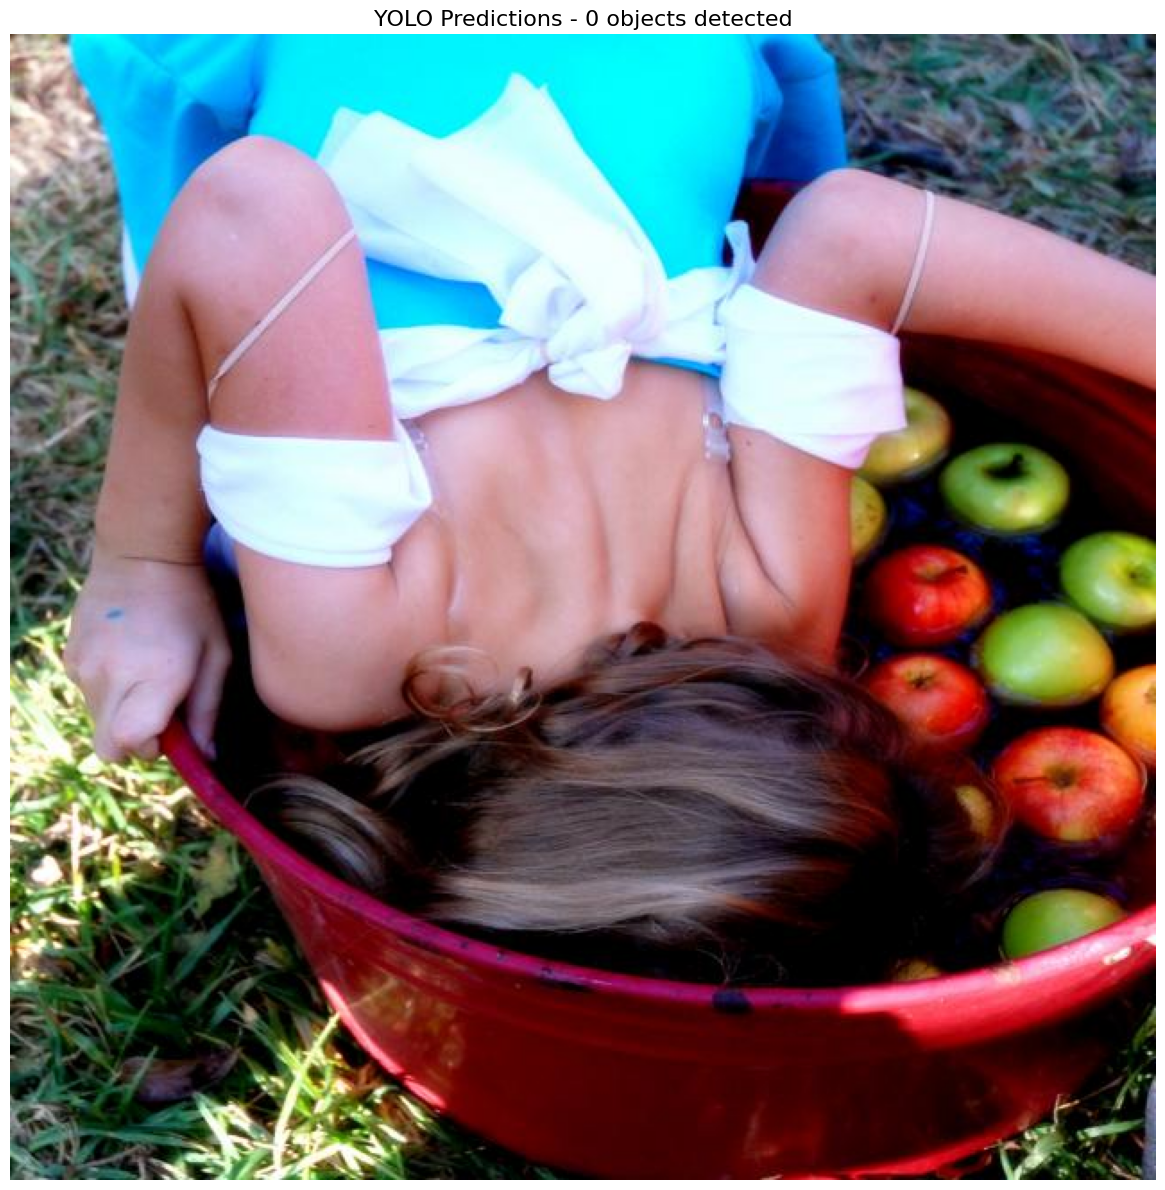

In [18]:
BASE_TEST_PATH = "/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test"

ids = "afd4e66481afd1b6_jpg.rf.fe2b55fb9817b9473b7b5561c5c1b733"  
fig, ax = visualize_yolo_predictions(model, BASE_TEST_PATH, ids, conf_threshold=0.5,ground_truth = False )

In [19]:
temp = "0026df6bcaf93ac5_jpg.rf.510f06f5d706b8924f3a8a411211dcf8.jpg".lstrip('0')
temp

'26df6bcaf93ac5_jpg.rf.510f06f5d706b8924f3a8a411211dcf8.jpg'

# Generate prediction 

In [20]:
import os
import csv
import json
import glob
from pathlib import Path
from tqdm import tqdm 

def generate_predictions_from_model(model, test_folder, output_csv_path, conf_threshold=0.5):
   
    image_paths = [test_folder +  f for f in sorted(os.listdir(test_folder)) if f.endswith('.jpg')]
    
    with open(output_csv_path, 'w', newline='') as csvfile:
        fieldnames = ['image_id', 'bounding_boxes']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        
        for image_path in tqdm(image_paths):
            file_name = Path(image_path).stem
            image_id = f"{file_name}"
            
            results = model.predict(image_path, conf=conf_threshold, verbose=False, device = 0)
            result = results[0]  
            
            boxes = result.boxes.xyxy.cpu().numpy()
            scores = result.boxes.conf.cpu().numpy()
            class_ids = result.boxes.cls.cpu().numpy().astype(int)
            
            bbox_list = []
            for box, score, class_id in zip(boxes, scores, class_ids):
                x_min, y_min, x_max, y_max = box
                bbox_obj = {
                    "x_min": float(x_min),
                    "y_min": float(y_min),
                    "x_max": float(x_max),
                    "y_max": float(y_max),
                    "class": int(class_id),
                    "confidence": float(score)
                }
                bbox_list.append(bbox_obj)
            if len(bbox_list ) != 0 : 
                bbox_json = json.dumps(bbox_list)
            else: bbox_json = "[]"
                
            writer.writerow({'image_id': image_id, 'bounding_boxes': bbox_json})
        
    
    print(f"Đã tạo file CSV tại: {output_csv_path}")
    return output_csv_path


In [21]:
generate_predictions_from_model(model, '/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test/images/', 'output.csv')

100%|██████████| 848/848 [00:16<00:00, 52.91it/s]

Đã tạo file CSV tại: output.csv


'output.csv'